Cross-dataset plots for Hi OOD-vs-Random-Shuffle analysis.

Reads the CSV tables produced by 01_cross_dataset_tables_hi.py and generates
5 paper-style figures:

  Figure 1 — Inner validation vs OOD test scatter (2×2 by dataset)
  Figure 2 — Protocol delta heatmap (validation optimism + test benefit)
  Figure 3 — Model complexity by protocol (3 panels by model family)
  Figure 4 — Top-k feature overlap between OOD and Random
  Figure 5 — Importance concentration summary

All figures are saved to:
  results/results_ood_vs_random_shuffle/hi/cross_dataset/figures/

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

In [2]:

try:
    PROJECT_ROOT = Path(__file__).resolve().parents[2]
except NameError:
    PROJECT_ROOT = Path.cwd()
    while PROJECT_ROOT.name != "drug-discovery-lohi" and PROJECT_ROOT.parent != PROJECT_ROOT:
        PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = (
    PROJECT_ROOT
    / "results"
    / "results_ood_vs_random_shuffle"
    / "hi"
    / "cross_dataset"
)

FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data dir:", DATA_DIR)
print("Figure dir:", FIG_DIR)

Project root: /home/f.capria/drug-discovery-lohi
Data dir: /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset
Figure dir: /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/figures


In [3]:
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 10,
    "font.family": "sans-serif",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 9,
})

PROTOCOL_COLORS = {
    "OOD holdout": "#2563EB",
    "Random shuffle": "#DC2626",
}
PROTOCOL_ORDER = ["OOD holdout", "Random shuffle"]

MODEL_MARKERS = {
    "Decision Tree": "o",
    "Logistic Regression": "s",
    "Linear SVM": "^",
}
MODEL_SHORT = {
    "Decision Tree": "DT",
    "Logistic Regression": "LR",
    "Linear SVM": "SVM",
}

DATASET_ORDER = ["drd2", "hiv", "kdr", "sol"]
DATASET_LABELS = {"drd2": "DRD2", "hiv": "HIV", "kdr": "KDR", "sol": "Sol"}

FP_MARKERS = {"ECFP4": "o", "MACCS": "s", "RDKit desc": "D"}


In [4]:
print("Loading cross-dataset tables …")

summary = pd.read_csv(DATA_DIR / "cross_dataset_protocol_summary.csv")
delta = pd.read_csv(DATA_DIR / "cross_dataset_protocol_delta.csv")
complexity_all = pd.read_csv(DATA_DIR / "cross_dataset_complexity_all.csv")
overlap = pd.read_csv(DATA_DIR / "cross_dataset_feature_overlap.csv")
concentration = pd.read_csv(DATA_DIR / "cross_dataset_feature_concentration.csv")

print(f"  summary:       {len(summary)} rows")
print(f"  delta:         {len(delta)} rows")
print(f"  complexity:    {len(complexity_all)} rows")
print(f"  overlap:       {len(overlap)} rows")
print(f"  concentration: {len(concentration)} rows")

Loading cross-dataset tables …
  summary:       56 rows
  delta:         28 rows
  complexity:    168 rows
  overlap:       504 rows
  concentration: 168 rows


## Inner validation vs OOD test scatter (2×2 by dataset)

In [5]:

def plot_figure1(summary: pd.DataFrame):
    datasets = [d for d in DATASET_ORDER if d in summary["dataset"].unique()]
    n = len(datasets)
    nrows, ncols = 2, 2

    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 10), squeeze=False)

    for idx, dataset in enumerate(datasets):
        ax = axes[idx // ncols, idx % ncols]
        sub = summary[summary["dataset"] == dataset]

        # Determine axis limits
        all_vals = pd.concat([sub["inner_mean"], sub["test_mean"]])
        lo = max(0, all_vals.min() - 0.05)
        hi = min(1, all_vals.max() + 0.05)
        lims = [lo, hi]

        ax.set_axisbelow(True)
        ax.grid(True, linestyle="--", color="lightgrey", alpha=0.5, zorder=0)

        # Identity diagonal
        ax.plot(lims, lims, ls="--", lw=1.2, color="#7f8c8d", zorder=1)
        ax.fill_between(
            lims, lims, [lims[0], lims[0]],
            alpha=0.03, color="#c0392b", zorder=0,
        )

        for _, row in sub.iterrows():
            protocol = row["protocol"]
            model = row["model"]
            ax.scatter(
                row["inner_mean"],
                row["test_mean"],
                c=PROTOCOL_COLORS[protocol],
                marker=MODEL_MARKERS.get(model, "o"),
                s=120,
                edgecolors="black",
                linewidths=0.5,
                alpha=0.85,
                zorder=3,
            )

        # Try to add text labels
        try:
            from adjustText import adjust_text
            texts = []
            for _, row in sub.iterrows():
                ms = MODEL_SHORT.get(row["model"], row["model"][:2])
                fp_short = row["fingerprint"][:1] if row["fingerprint"] != "RDKit desc" else "R"
                label = f"{ms}+{fp_short}"
                texts.append(ax.text(
                    row["inner_mean"], row["test_mean"], label,
                    fontsize=7, color="#333333",
                ))
            adjust_text(texts, ax=ax,
                        arrowprops=dict(arrowstyle="-", color="grey",
                                        lw=0.4, alpha=0.4))
        except ImportError:
            pass

        ax.set_xlim(lims)
        ax.set_ylim(lims)
        ax.set_aspect("equal")
        ax.set_xlabel("Mean inner validation PR-AUC", fontsize=10)
        ax.set_ylabel("Mean final OOD test PR-AUC", fontsize=10)
        ax.set_title(DATASET_LABELS.get(dataset, dataset),
                      fontsize=13, fontweight="bold", pad=8)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # Hide unused panels
    for idx in range(len(datasets), nrows * ncols):
        axes[idx // ncols, idx % ncols].set_visible(False)

    # Shared legend
    protocol_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
               markersize=10, markeredgecolor="black", markeredgewidth=0.5,
               label=p)
        for p, c in PROTOCOL_COLORS.items()
    ]
    model_handles = [
        Line2D([0], [0], marker=m, color="w", markerfacecolor="grey",
               markersize=10, markeredgecolor="black", markeredgewidth=0.5,
               label=MODEL_SHORT[name])
        for name, m in MODEL_MARKERS.items()
    ]
    fig.legend(
        handles=protocol_handles + model_handles,
        loc="lower center", ncol=5, fontsize=9,
        bbox_to_anchor=(0.5, -0.02), frameon=False,
    )

    fig.suptitle(
        "Inner Validation vs Final OOD Test PR-AUC — Hi Tasks",
        fontsize=14, fontweight="bold", y=1.02,
    )
    fig.tight_layout()
    fname = FIG_DIR / "fig1_inner_vs_test_scatter.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname.name}")
    plt.show()
    plt.close(fig)

## Protocol delta heatmap

In [6]:

def plot_figure2(delta: pd.DataFrame):
    if len(delta) == 0:
        print("No delta data — skipping Figure 2.")
        return

    plot_df = delta.copy()
    plot_df["experiment"] = (
        plot_df["dataset_label"] + " | "
        + plot_df["model_short"] + " + "
        + plot_df["fingerprint"]
    )

    # Sort
    for col, order in [("dataset", {"drd2": 0, "hiv": 1, "kdr": 2, "sol": 3}),
                       ("model", {"Decision Tree": 0, "Logistic Regression": 1, "Linear SVM": 2}),
                       ("fingerprint", {"ECFP4": 0, "MACCS": 1, "RDKit desc": 2})]:
        plot_df[f"_ord_{col}"] = plot_df[col].map(order)
    plot_df = plot_df.sort_values(
        ["_ord_dataset", "_ord_model", "_ord_fingerprint"]
    ).reset_index(drop=True)

    experiments = plot_df["experiment"].tolist()
    metrics = ["delta_inner_optimism", "delta_test_benefit"]
    metric_labels = {
        "delta_inner_optimism": "Validation optimism\n(inner_rand − inner_OOD)",
        "delta_test_benefit": "OOD test benefit\n(test_OOD − test_rand)",
    }

    mat = plot_df[metrics].values
    vmax = max(abs(np.nanmin(mat)), abs(np.nanmax(mat)), 0.001)
    norm = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)

    fig, ax = plt.subplots(figsize=(7, max(4, 0.45 * len(experiments))))

    im = ax.imshow(mat, aspect="auto", cmap="RdBu_r", norm=norm)

    ax.set_yticks(range(len(experiments)))
    ax.set_yticklabels(experiments, fontsize=9)
    ax.set_xticks(range(len(metrics)))
    ax.set_xticklabels([metric_labels[m] for m in metrics], fontsize=10)
    ax.xaxis.tick_top()

    for i in range(len(experiments)):
        for j in range(len(metrics)):
            val = mat[i, j]
            if np.isnan(val):
                continue
            text_color = "white" if abs(val) > vmax * 0.55 else "black"
            ax.text(j, i, f"{val:+.3f}", ha="center", va="center",
                    fontsize=9, fontweight="bold", color=text_color)

    # Horizontal separators between datasets
    prev_ds = plot_df.iloc[0]["dataset"]
    for i in range(1, len(plot_df)):
        if plot_df.iloc[i]["dataset"] != prev_ds:
            ax.axhline(i - 0.5, color="black", linewidth=1.5, zorder=5)
            prev_ds = plot_df.iloc[i]["dataset"]

    ax.set_xticks(np.arange(-0.5, len(metrics), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(experiments), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=2)
    ax.tick_params(which="minor", bottom=False, left=False, top=False)

    cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.03)
    cbar.set_label("Δ PR-AUC", fontsize=10)

    ax.set_title(
        "Protocol Effect: Validation Optimism & OOD Test Benefit — Hi Tasks",
        fontsize=13, fontweight="bold", pad=20,
    )

    fig.tight_layout()
    fname = FIG_DIR / "fig2_protocol_delta_heatmap.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname.name}")
    plt.show()
    plt.close(fig)

## Model complexity by protocol

In [7]:

def _strip_plot_cross(ax, data, x_col, y_col, color_map, jitter_width=0.12):
    """Strip plot with fold-level points and mean horizontal lines."""
    categories = data[x_col].unique()
    x_positions = np.arange(len(categories))
    cat_to_x = dict(zip(categories, x_positions))

    for _, row in data.iterrows():
        x_base = cat_to_x[row[x_col]]
        jitter = (row["fold"] - 2) * jitter_width
        color = color_map[row["protocol"]]
        ax.scatter(
            x_base + jitter, row[y_col],
            c=color, s=40, alpha=0.65, edgecolors="white",
            linewidths=0.3, zorder=3,
        )

    for cat in categories:
        x_base = cat_to_x[cat]
        for protocol in PROTOCOL_ORDER:
            mask = (data[x_col] == cat) & (data["protocol"] == protocol)
            vals = data.loc[mask, y_col]
            if len(vals) == 0:
                continue
            ax.hlines(
                vals.mean(), x_base - 0.25, x_base + 0.25,
                colors=color_map[protocol], linewidths=2.2, zorder=4,
            )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(categories, rotation=35, ha="right", fontsize=8)


def plot_figure3(complexity_all: pd.DataFrame):
    if len(complexity_all) == 0:
        print("No complexity data — skipping Figure 3.")
        return

    model_configs = [
        ("Decision Tree", "DT", "n_nodes", "Number of tree nodes"),
        ("Logistic Regression", "LR", "l2_norm", "L2 norm of coefficients"),
        ("Linear SVM", "SVM", "l2_norm", "L2 norm of weights"),
    ]

    available_models = [
        cfg for cfg in model_configs
        if cfg[0] in complexity_all["model"].unique()
        and cfg[2] in complexity_all.columns
    ]

    if not available_models:
        print("No complexity indicators available — skipping Figure 3.")
        return

    n_panels = len(available_models)
    fig, axes = plt.subplots(1, n_panels, figsize=(5.5 * n_panels, 5.5),
                              sharey=False, squeeze=False)

    for i, (model, ms, y_col, y_label) in enumerate(available_models):
        ax = axes[0, i]
        sub = complexity_all[complexity_all["model"] == model].copy()
        sub = sub.dropna(subset=[y_col])

        if len(sub) == 0:
            ax.set_title(f"{ms}\n(no data)")
            continue

        # Build x-axis label: Dataset + FP
        sub["x_label"] = (
            sub["dataset"].map(DATASET_LABELS).fillna(sub["dataset"])
            + "\n" + sub["fingerprint"]
        )
        # Sort x labels
        sub["_ds_ord"] = sub["dataset"].map(
            {"drd2": 0, "hiv": 1, "kdr": 2, "sol": 3})
        sub["_fp_ord"] = sub["fingerprint"].map(
            {"ECFP4": 0, "MACCS": 1, "RDKit desc": 2})
        sub = sub.sort_values(["_ds_ord", "_fp_ord"]).reset_index(drop=True)

        # Deduplicate x_label order
        x_labels_ordered = list(dict.fromkeys(sub["x_label"]))
        sub["x_label"] = pd.Categorical(
            sub["x_label"], categories=x_labels_ordered, ordered=True
        )

        _strip_plot_cross(ax, sub, "x_label", y_col, PROTOCOL_COLORS)

        ax.set_ylabel(y_label, fontsize=11, weight="medium")
        ax.set_title(ms, fontsize=13, fontweight="bold", pad=10)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="--", color="lightgrey", alpha=0.7)
        ax.set_xlabel("")

    legend_handles = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=c,
               markersize=10, markeredgecolor="black", markeredgewidth=0.5,
               label=p)
        for p, c in PROTOCOL_COLORS.items()
    ]
    fig.legend(
        handles=legend_handles, loc="lower center", ncol=2, fontsize=10,
        bbox_to_anchor=(0.5, -0.04), frameon=False,
    )
    fig.suptitle(
        "Model Complexity by Inner Validation Protocol — Hi Tasks",
        fontsize=14, fontweight="bold", y=1.03,
    )
    fig.tight_layout()
    fname = FIG_DIR / "fig3_complexity_by_protocol.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname.name}")
    plt.show()
    plt.close(fig)

## Top-k feature overlap between OOD and Random

In [8]:
def plot_figure4(overlap: pd.DataFrame):
    if len(overlap) == 0:
        print("No overlap data — skipping Figure 4.")
        return

    # Aggregate: mean overlap per dataset × model × fingerprint × k
    agg = (
        overlap
        .groupby(["dataset", "model", "fingerprint", "top_k"], as_index=False)
        .agg(
            overlap_mean=("overlap_percent", "mean"),
            overlap_std=("overlap_percent", "std"),
        )
    )

    models = [
        m for m in ["Decision Tree", "Logistic Regression", "Linear SVM"]
        if m in agg["model"].unique()
    ]

    n_models = len(models)

    if n_models == 0:
        print("No models in overlap data — skipping Figure 4.")
        return

    ks = sorted(agg["top_k"].unique())

    fig, axes = plt.subplots(
        1,
        n_models,
        figsize=(5.5 * n_models, 5),
        sharey=True,
        squeeze=False,
    )

    for mi, model in enumerate(models):
        ax = axes[0, mi]
        sub = agg[agg["model"] == model].copy()

        sub["group"] = (
            sub["dataset"].map(DATASET_LABELS).fillna(sub["dataset"])
            + "\n" + sub["fingerprint"]
        )

        sub["_ds_ord"] = sub["dataset"].map(
            {"drd2": 0, "hiv": 1, "kdr": 2, "sol": 3}
        )
        sub["_fp_ord"] = sub["fingerprint"].map(
            {"ECFP4": 0, "MACCS": 1, "RDKit desc": 2}
        )

        sub = sub.sort_values(["_ds_ord", "_fp_ord"]).reset_index(drop=True)
        groups = list(dict.fromkeys(sub["group"]))

        n_groups = len(groups)
        n_k = len(ks)
        bar_width = 0.8 / n_k
        k_colors = plt.cm.viridis(np.linspace(0.25, 0.85, n_k))

        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

        for ki, k in enumerate(ks):
            k_sub = sub[sub["top_k"] == k]

            x_vals = []
            y_vals = []
            e_vals = []

            for gi, grp in enumerate(groups):
                row = k_sub[k_sub["group"] == grp]
                x_vals.append(gi + (ki - n_k / 2 + 0.5) * bar_width)

                if len(row) > 0:
                    y_vals.append(float(row["overlap_mean"].values[0]))
                    std_val = row["overlap_std"].values[0]
                    e_vals.append(0.0 if np.isnan(std_val) else float(std_val))
                else:
                    y_vals.append(0.0)
                    e_vals.append(0.0)

            ax.bar(
                x_vals,
                y_vals,
                width=bar_width,
                yerr=e_vals,
                color=k_colors[ki],
                alpha=0.8,
                capsize=3,
                edgecolor="white",
                linewidth=0.5,
                label=f"Top-{k}" if mi == 0 else None,
                zorder=3,
            )

        ax.set_xticks(range(n_groups))
        ax.set_xticklabels(groups, fontsize=8, rotation=35, ha="right")
        ax.set_ylim(0, 105)
        ax.axhline(100, color="grey", linestyle="--", linewidth=0.8, alpha=0.5)

        ax.set_title(
            MODEL_SHORT.get(model, model),
            fontsize=13,
            fontweight="bold",
            pad=8,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0, 0].set_ylabel("Feature overlap %", fontsize=11, weight="medium")

    handles = [
        plt.Rectangle((0, 0), 1, 1, fc=k_colors[ki], alpha=0.8)
        for ki in range(n_k)
    ]
    labels = [f"Top-{k}" for k in ks]

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=n_k,
        fontsize=10,
        bbox_to_anchor=(0.5, -0.04),
        frameon=False,
    )

    fig.suptitle(
        "Top-k Feature Overlap: OOD Holdout vs Random Shuffle — Hi Tasks",
        fontsize=14,
        fontweight="bold",
        y=1.03,
    )

    fig.tight_layout()

    fname = FIG_DIR / "fig4_topk_feature_overlap.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname.name}")

    plt.show()
    plt.close(fig)

## Importance concentration summary

In [9]:

def plot_figure5(concentration: pd.DataFrame):
    """
    Figure 5 — Importance concentration summary.

    Shows how much positive importance is captured by the top-k features.
    Fractions are computed in the tables script using clipped non-negative
    importance values.
    """
    if len(concentration) == 0:
        print("No concentration data — skipping Figure 5.")
        return

    frac_cols = [
        c for c in ["fraction_top_10", "fraction_top_20", "fraction_top_50"]
        if c in concentration.columns
    ]

    if not frac_cols:
        print("No fraction_top_* columns — skipping Figure 5.")
        return

    k_labels = {
        "fraction_top_10": "Top-10",
        "fraction_top_20": "Top-20",
        "fraction_top_50": "Top-50",
    }

    # Aggregate across folds.
    group_cols = ["dataset", "model", "model_short", "fingerprint", "protocol"]
    agg = concentration.groupby(group_cols, as_index=False)[frac_cols].mean()

    models = [
        m for m in ["Decision Tree", "Logistic Regression", "Linear SVM"]
        if m in agg["model"].unique()
    ]

    if not models:
        print("No models in concentration data — skipping Figure 5.")
        return

    fig, axes = plt.subplots(
        1,
        len(models),
        figsize=(5.8 * len(models), 5.2),
        sharey=True,
        squeeze=False,
    )

    # One color per top-k level.
    k_colors = plt.cm.viridis(np.linspace(0.25, 0.85, len(frac_cols)))

    for mi, model in enumerate(models):
        ax = axes[0, mi]
        sub = agg[agg["model"] == model].copy()

        sub["group"] = (
            sub["dataset"].map(DATASET_LABELS).fillna(sub["dataset"])
            + "\n" + sub["fingerprint"]
        )

        sub["_ds_ord"] = sub["dataset"].map(
            {"drd2": 0, "hiv": 1, "kdr": 2, "sol": 3}
        )
        sub["_fp_ord"] = sub["fingerprint"].map(
            {"ECFP4": 0, "MACCS": 1, "RDKit desc": 2}
        )
        sub["_protocol_ord"] = sub["protocol"].map(
            {"OOD holdout": 0, "Random shuffle": 1}
        )

        sub = sub.sort_values(
            ["_ds_ord", "_fp_ord", "_protocol_ord"]
        ).reset_index(drop=True)

        groups = list(dict.fromkeys(sub["group"]))
        x = np.arange(len(groups))

        n_protocols = len(PROTOCOL_ORDER)
        n_k = len(frac_cols)

        # Within each dataset/fingerprint group:
        # protocol blocks are separated, and top-k bars are grouped inside.
        total_width = 0.82
        protocol_width = total_width / n_protocols
        bar_width = protocol_width / n_k

        ax.set_axisbelow(True)
        ax.grid(axis="y", linestyle="--", alpha=0.5, zorder=0)

        for pi, protocol in enumerate(PROTOCOL_ORDER):
            p_sub = sub[sub["protocol"] == protocol]

            for ki, fc in enumerate(frac_cols):
                x_vals = []
                y_vals = []

                for gi, grp in enumerate(groups):
                    row = p_sub[p_sub["group"] == grp]

                    offset = (
                        -total_width / 2
                        + pi * protocol_width
                        + ki * bar_width
                        + bar_width / 2
                    )

                    x_vals.append(gi + offset)

                    if len(row) > 0:
                        y_vals.append(float(row[fc].values[0]) * 100)
                    else:
                        y_vals.append(0.0)

                hatch = "" if protocol == "OOD holdout" else "//"

                label = None
                if mi == 0:
                    label = f"{protocol}, {k_labels.get(fc, fc)}"

                ax.bar(
                    x_vals,
                    y_vals,
                    width=bar_width,
                    color=k_colors[ki],
                    hatch=hatch,
                    edgecolor="black",
                    linewidth=0.35,
                    alpha=0.85,
                    zorder=3,
                    label=label,
                )

        ax.set_xticks(x)
        ax.set_xticklabels(groups, fontsize=8, rotation=35, ha="right")
        ax.set_ylim(0, 105)

        ax.set_title(
            MODEL_SHORT.get(model, model),
            fontsize=13,
            fontweight="bold",
            pad=8,
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    axes[0, 0].set_ylabel(
        "Cumulative positive importance (%)",
        fontsize=11,
        weight="medium",
    )

    # Compact legend.
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        fontsize=8,
        bbox_to_anchor=(0.5, -0.08),
        frameon=False,
    )

    fig.suptitle(
        "Feature Importance Concentration — Hi Tasks",
        fontsize=14,
        fontweight="bold",
        y=1.03,
    )

    fig.tight_layout()

    fname = FIG_DIR / "fig5_importance_concentration.png"
    fig.savefig(fname, bbox_inches="tight")
    print(f"Saved: {fname.name}")
    plt.show()
    plt.close(fig)

In [10]:
def main():
    print(f"\nFigure output directory: {FIG_DIR}\n")

    print("--- Figure 1: Inner vs OOD test scatter ---")
    plot_figure1(summary)

    print("--- Figure 2: Protocol delta heatmap ---")
    plot_figure2(delta)

    print("--- Figure 3: Complexity by protocol ---")
    plot_figure3(complexity_all)

    print("--- Figure 4: Top-k feature overlap ---")
    plot_figure4(overlap)

    print("--- Figure 5: Importance concentration ---")
    plot_figure5(concentration)

    print(f"\nDone. All figures saved to:\n  {FIG_DIR}")

    return {
        "summary": summary,
        "delta": delta,
        "complexity_all": complexity_all,
        "overlap": overlap,
        "concentration": concentration,
        "fig_dir": FIG_DIR,
    }


Figure output directory: /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/figures

--- Figure 1: Inner vs OOD test scatter ---
Saved: fig1_inner_vs_test_scatter.png


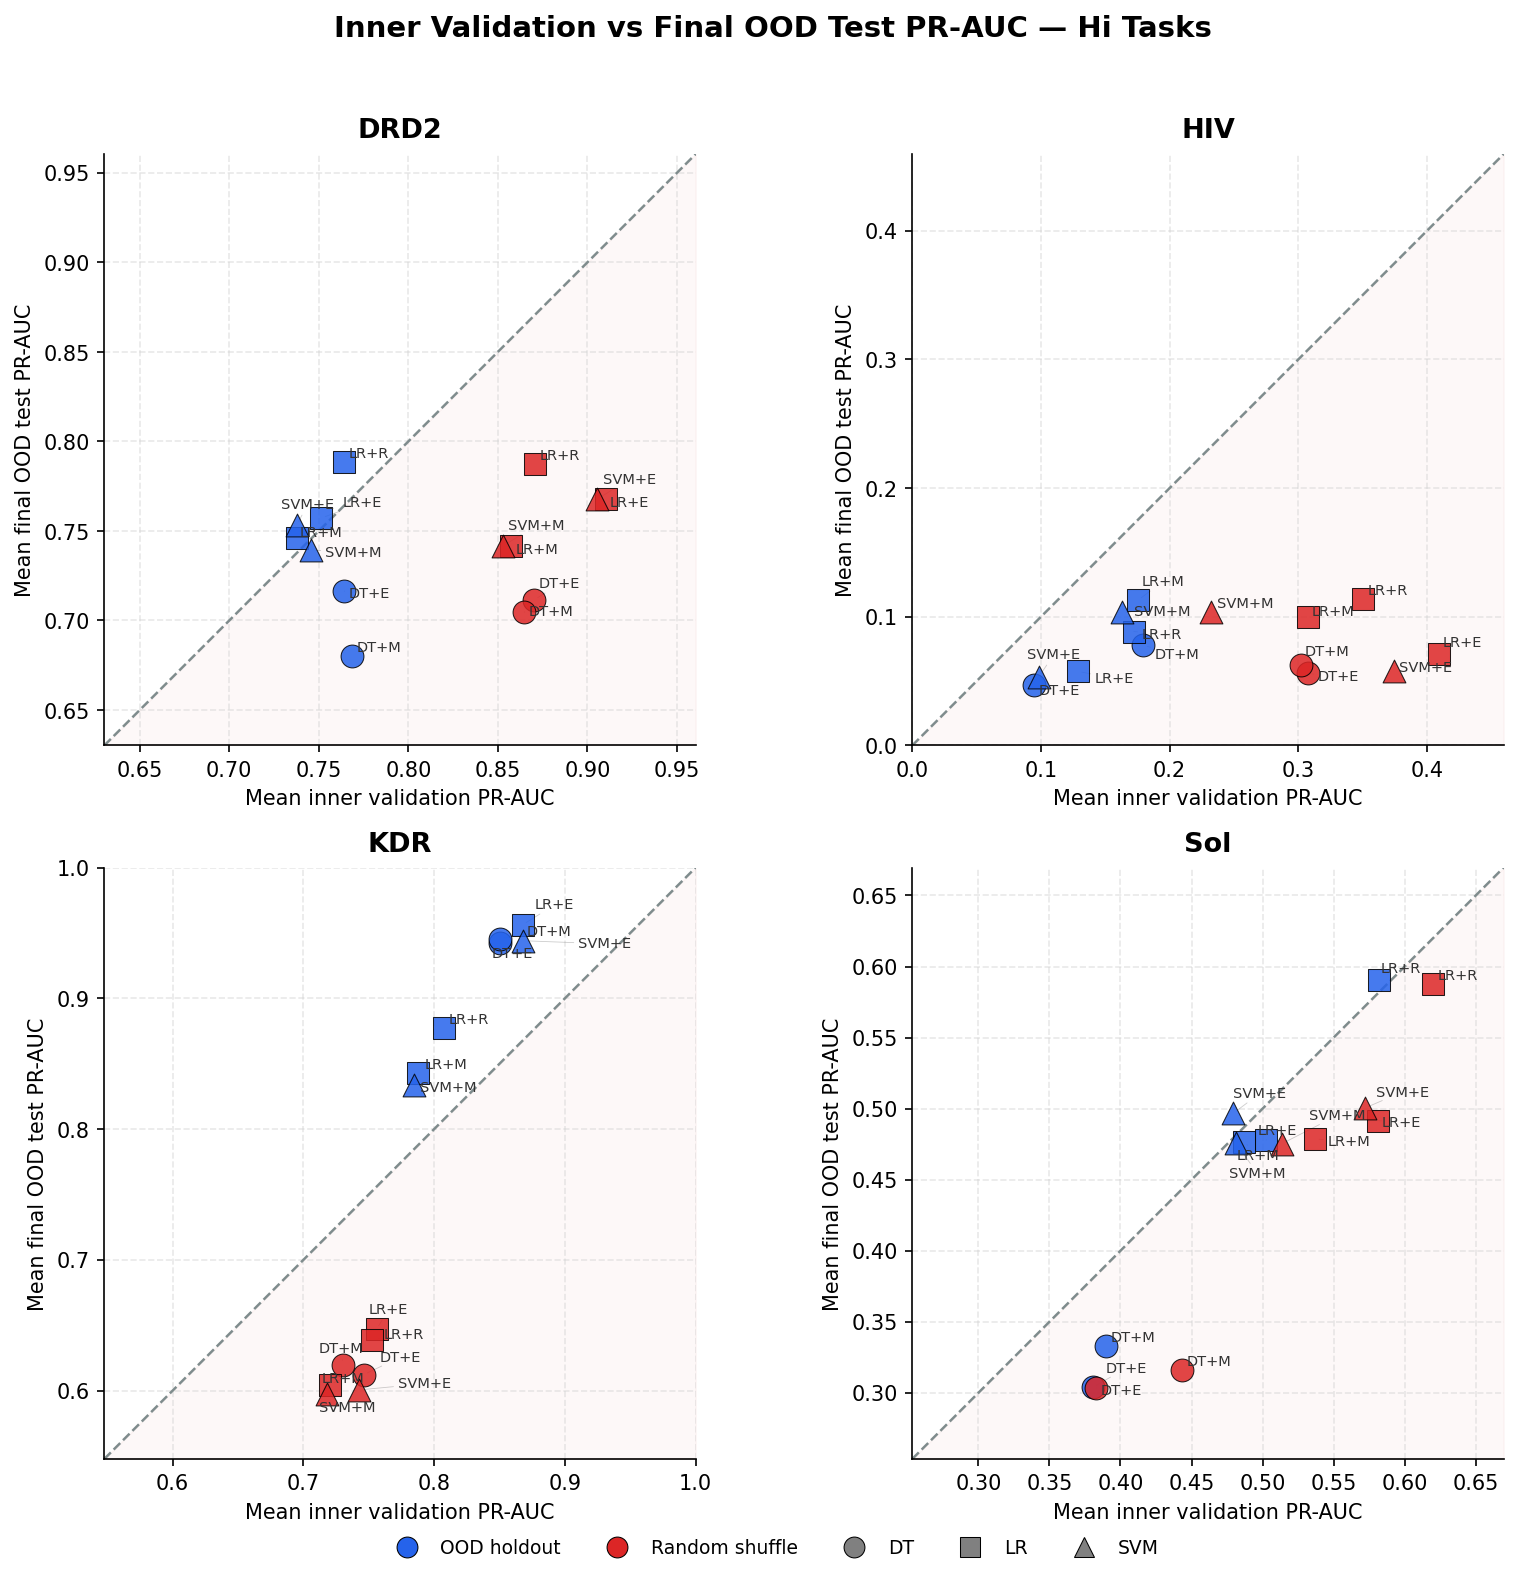

--- Figure 2: Protocol delta heatmap ---
Saved: fig2_protocol_delta_heatmap.png


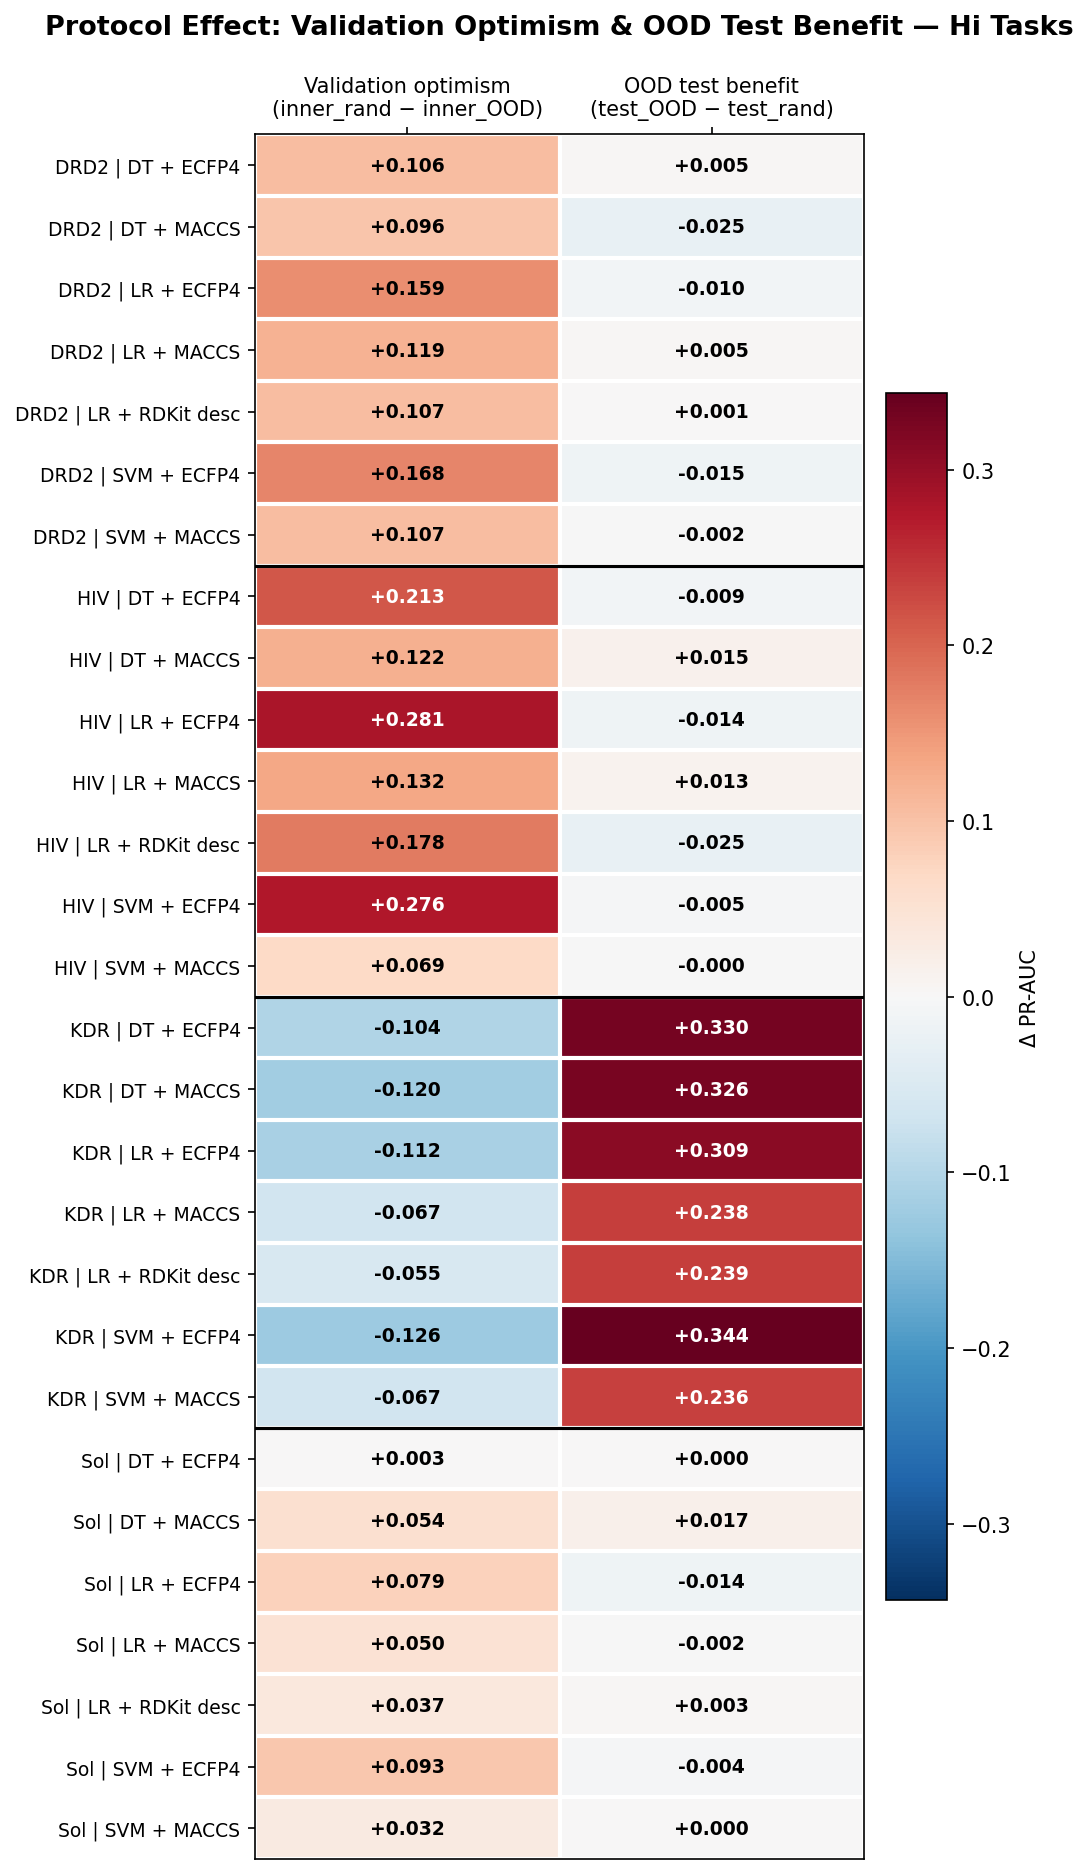

--- Figure 3: Complexity by protocol ---
Saved: fig3_complexity_by_protocol.png


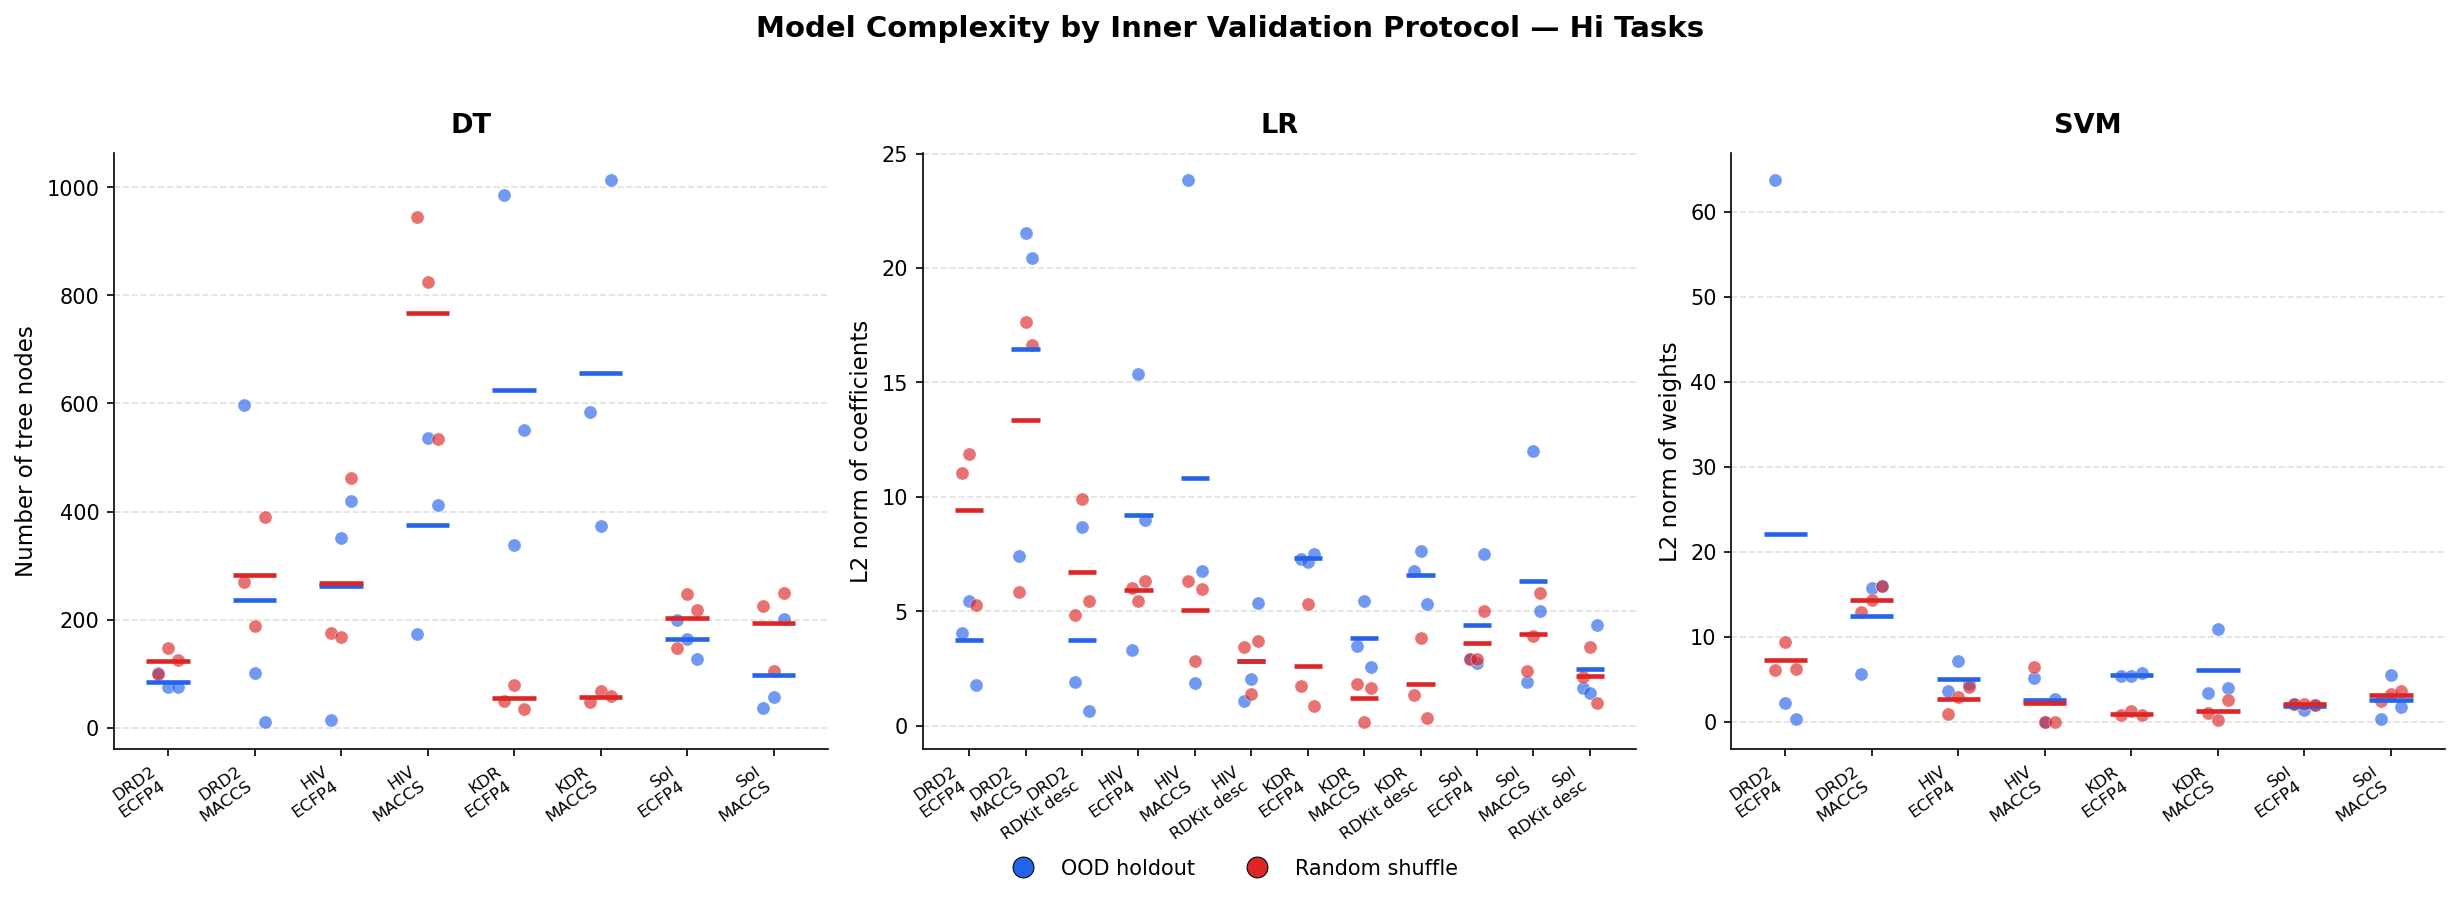

--- Figure 4: Top-k feature overlap ---
Saved: fig4_topk_feature_overlap.png


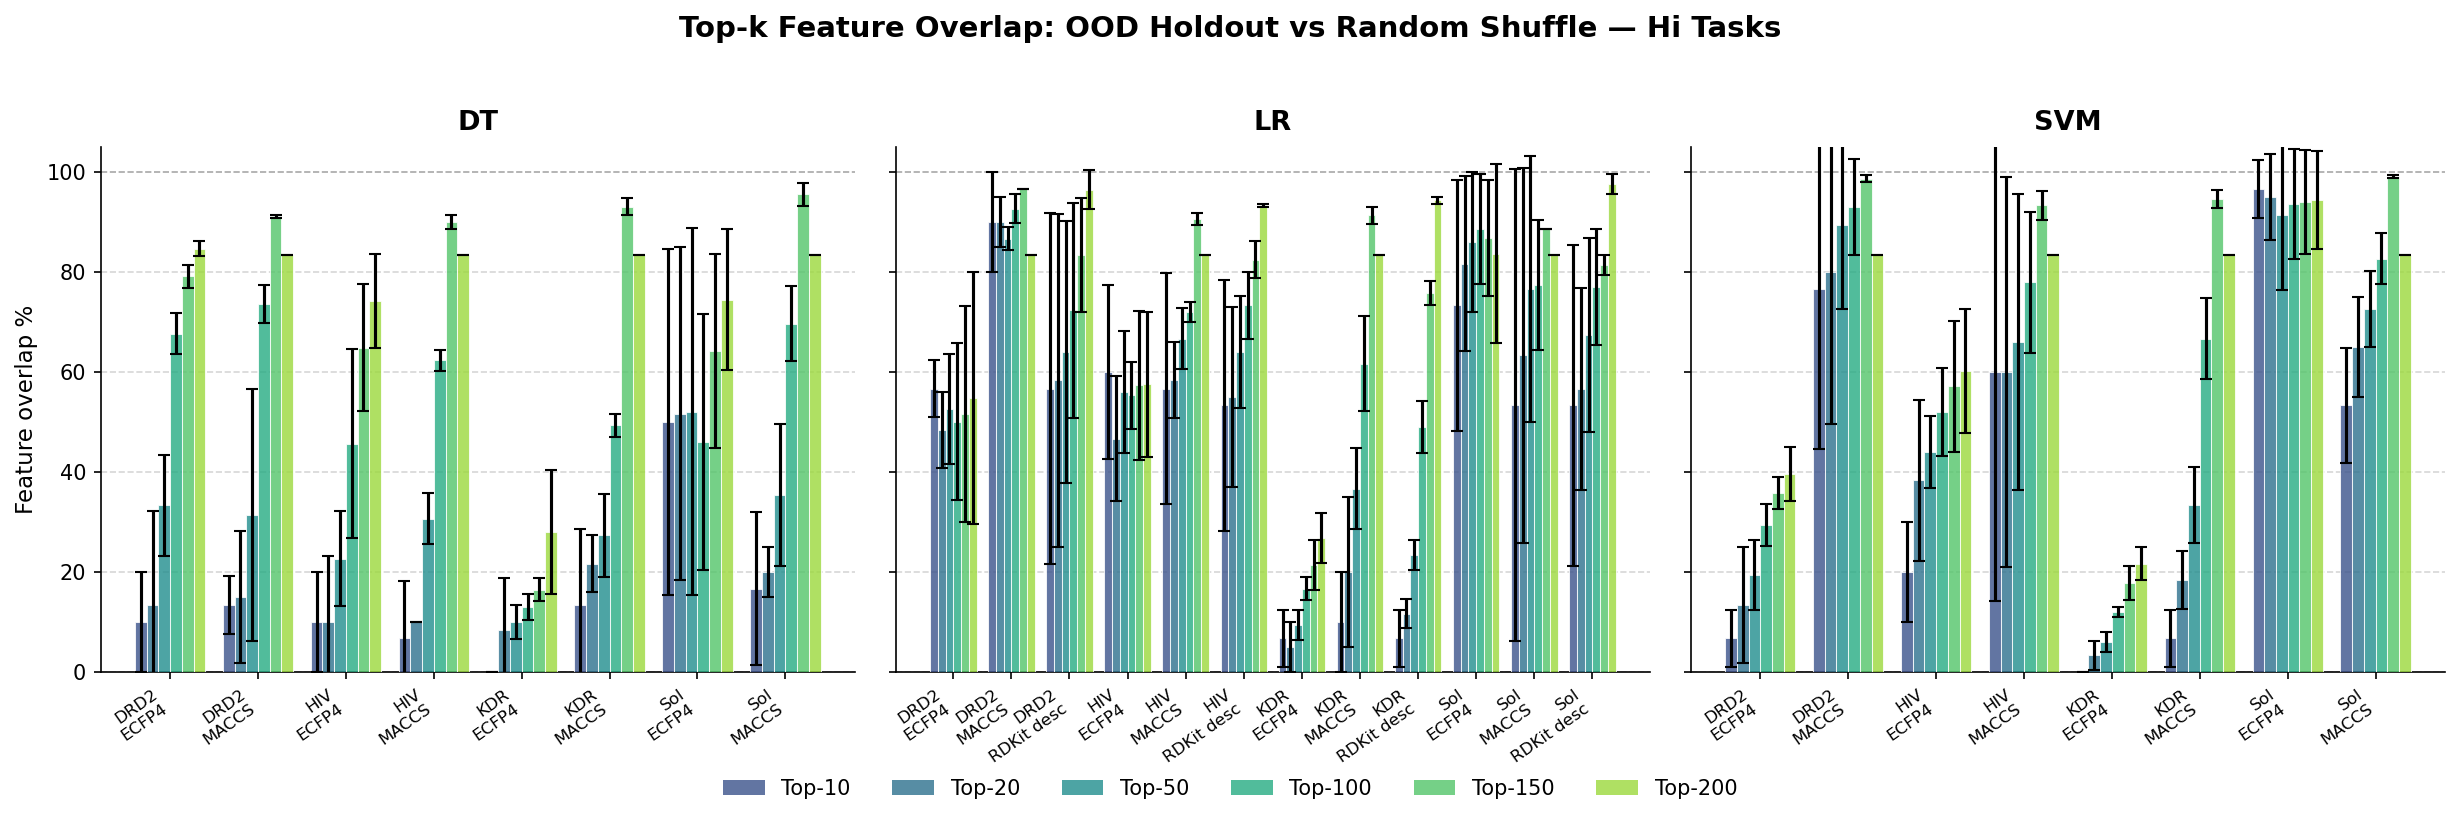

--- Figure 5: Importance concentration ---
Saved: fig5_importance_concentration.png


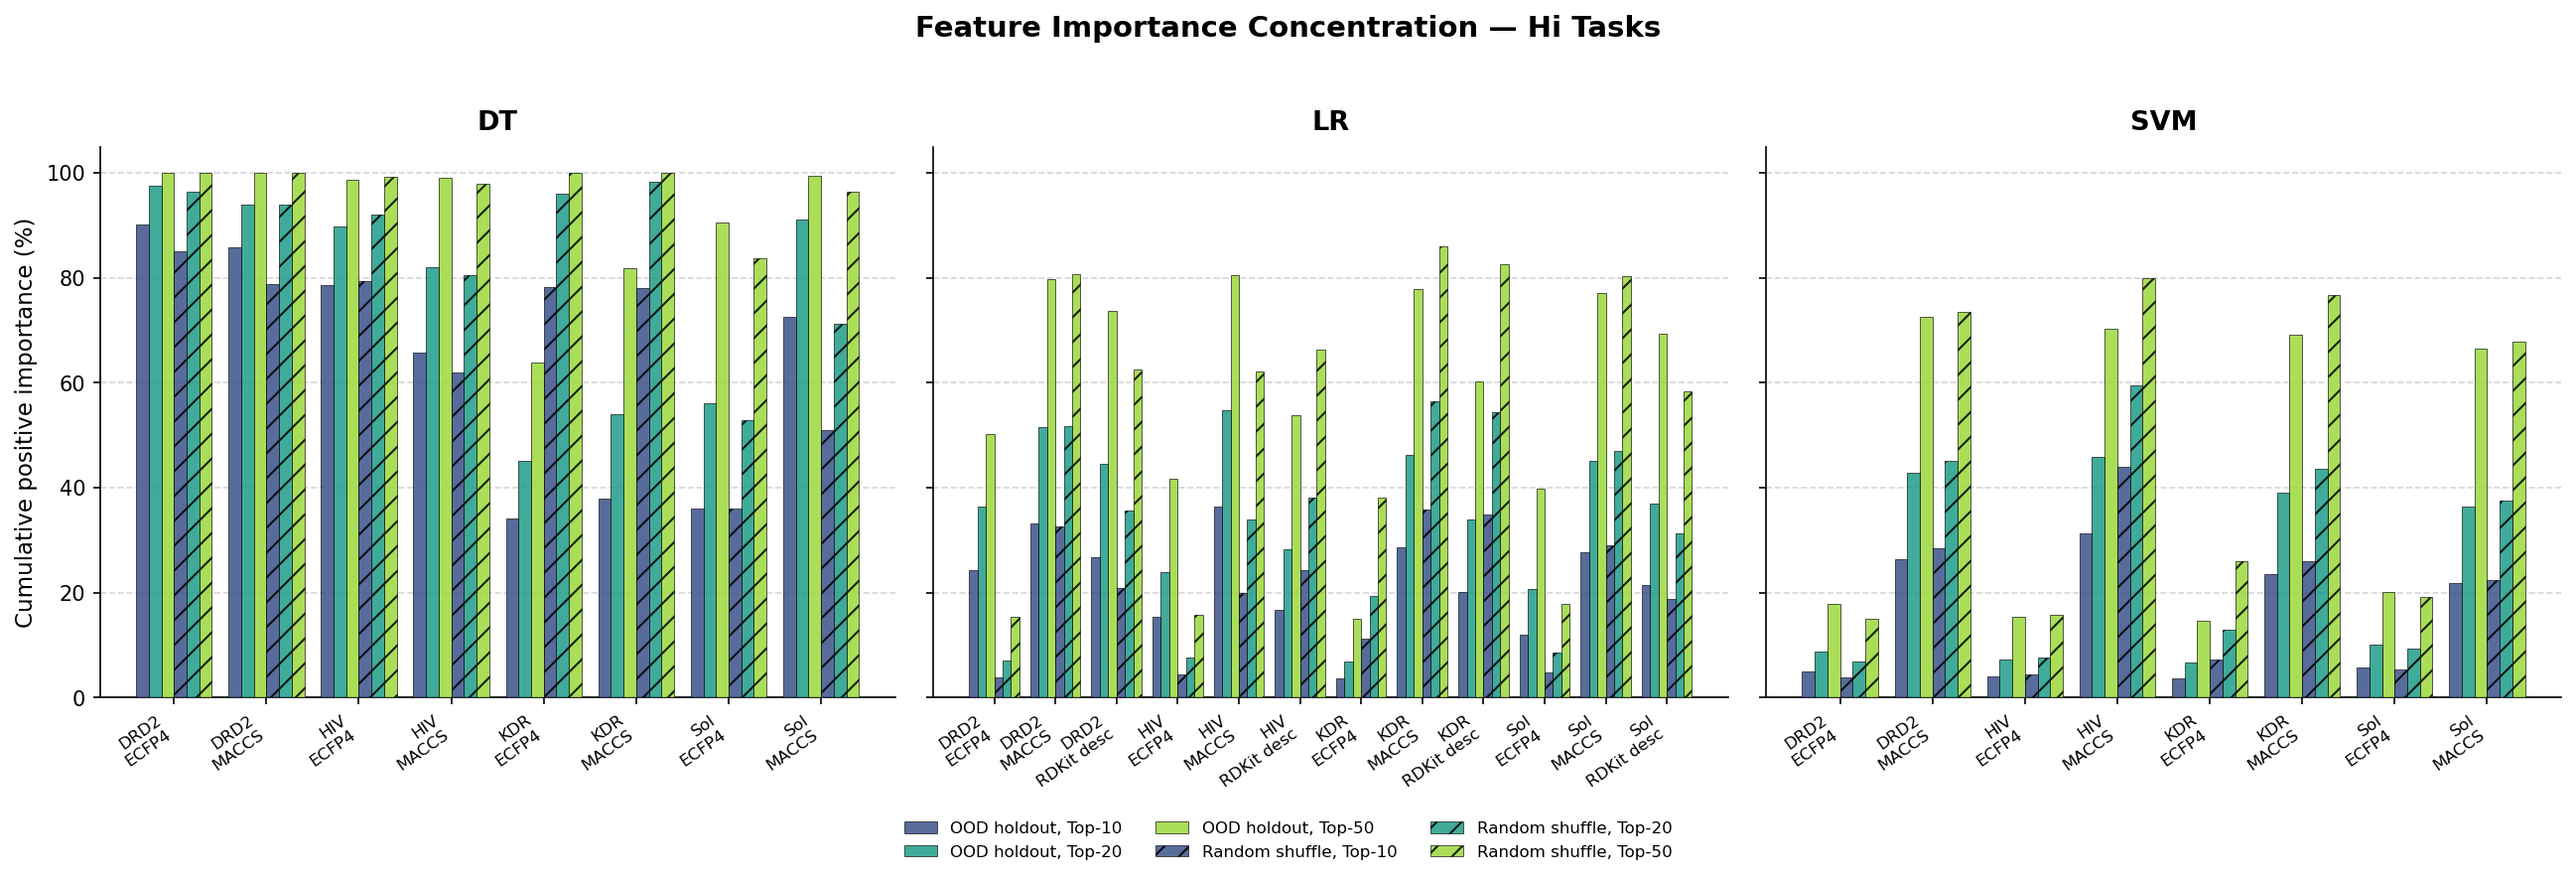


Done. All figures saved to:
  /home/f.capria/drug-discovery-lohi/results/results_ood_vs_random_shuffle/hi/cross_dataset/figures


In [11]:
plot_outputs = main()